# Two-Point Seismic Inverse Problem Demo

**Problem setting.**  
An earthquake occurs at an unknown location $x \in \mathbb{S}^2$.  Two sensors at $y_1, y_2 \in \mathbb{S}^2$ record signals
$$I(x,y) = \exp\!\bigl(\beta(\langle x,y\rangle - 1)\bigr), \qquad U_i \mid x,y_i \sim \mathcal{N}(I(x,y_i),\sigma^2).$$
Given measurements $(u_1,y_1),(u_2,y_2)$ we recover $x$ using **DPnP**.

**Features of this demo:**
- `n_sensor_pairs` (S) × `n_trials_per_sensor` (T) — all batched in one DPnP call.
- **Reflection point** $x'$: the unique point on $\mathbb{S}^2$ with *identical seismic likelihood* as $x_\mathrm{true}$, obtained by reflecting $x_\mathrm{true}$ through $\mathrm{span}(y_1,y_2)$. Shown as a purple ✗.
- **MCMC baseline** (`include_baseline=True`): samples from $q(x) \propto p(u_1|x,y_1)\,p(u_2|x,y_2)$ via **geodesic random-walk Metropolis** on $\mathbb{S}^2$ — **no score network involved**. At each step: $z\sim\mathcal{N}(0,I_3)$, $v=(I-xx^\top)z$, $x^*=\mathrm{Exp}_x(\tau v)$, accept with probability $\min\{1,q(x^*)/q(x)\}$. This is the correct likelihood-only baseline. DPnP with $p_\text{score}\equiv 0$ is *not* equivalent because BEL bridge paths use $p(x_0|x_t)\propto p(x_t|x_0)\,p_0(x_0)$, which encodes the earthquake prior $p_0$ regardless of $p_\text{score}$.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from data import make_earth_dataloaders
from model import AmbientGeneratorScoreNet, DPnPScoreWrapper
from bel import get_bel
from utils import (
    normalize_torch,
    sample_vmf_s2,
    sample_xtrue_y_batches_from_dataloader,
    seismic_signal,
    get_seismic_f_fn,
    get_two_point_seismic_f_fn,
    extrinsic_to_latlon_deg_torch,
    sphere_mean_torch,
)
from test_earth import (
    run_two_point_earthquake_demo,
    cosine_similarity_vs_steps_two_point,
    plot_spherical_kde_mollweide,
    _reflect_through_great_circle,
    tune_mala_tau,
)

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype  = torch.float32
print(f"Using device: {device}")

## 1. Load earthquake data and trained prior score

In [2]:
batch_size = 512
seed = 0
train_loader, val_loader, test_loader, dataset = make_earth_dataloaders(
    data_dir="data",
    name="earthquake",
    batch_size=batch_size,
    seed=seed,
    device="cpu",
)
print(f"Dataset size: {len(dataset)}")

hidden_dim      = 512
n_hidden_layers = 5
MODEL_PATH      = "checkpoint/best.pt"   # adjust path if needed

p_model = AmbientGeneratorScoreNet(hidden_dim=hidden_dim, n_hidden_layers=n_hidden_layers)
p_model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu", weights_only=False)['model'])
p_model.eval().to(device)
p_score = DPnPScoreWrapper(p_model)
print("Prior score model loaded.")

Dataset size: 6120
Prior score model loaded.


## 2. DPnP schedule and seismic model parameters

In [3]:
def aneal_schedule(K=20, K0=5, eta0=0.45, etaK=0.15):
    etas = np.zeros(K)
    for i in range(K):
        if i < K0:
            etas[i] = eta0
        else:
            frac = (i - K0) / (K - K0)
            etas[i] = eta0 * (etaK / eta0) ** frac
    return etas

eta = aneal_schedule(K=20, K0=5, eta0=0.1, etaK=0.05)

BETA   = 10.0    # signal decay; higher = sharper peak around y
SIGMA2 = 0.05    # observation noise variance
print(f"beta={BETA}, sigma2={SIGMA2}")

beta=10.0, sigma2=0.05


## 3. Choose x_true

Sample from the earthquake test set, or specify lat/lon directly.

In [4]:
# --- Option A: sample from test set ---
x_true_candidates, _ = sample_xtrue_y_batches_from_dataloader(
    dataloader=test_loader, sigma_y=1.0, num_pairs=batch_size,
    device=device, dtype=dtype, seed=1018,
)
x_true = x_true_candidates[329]

# --- Option B: specify lat/lon (uncomment) ---
# import math
# lat_deg, lon_deg = 35.0, 139.0   # near Tokyo
# lat, lon = math.radians(lat_deg), math.radians(lon_deg)
# x_true = normalize_torch(torch.tensor(
#     [math.cos(lat)*math.cos(lon), math.cos(lat)*math.sin(lon), math.sin(lat)],
#     dtype=dtype, device=device))

ll = extrinsic_to_latlon_deg_torch(x_true[None]).squeeze()
print(f"x_true  (lat, lon) = ({ll[0].item():.2f}°, {ll[1].item():.2f}°)")

x_true  (lat, lon) = (-27.23°, -76.93°)


## 4. Demo A – fixed sensor locations

Sensors `y1`, `y2` are specified manually (random on the sphere here).

y1 (lat, lon) = (27.46°, -103.37°)
y2 (lat, lon) = (-0.01°, -148.90°)
x' reflection (lat, lon) = (70.92°, 178.53°)
Sampled 6 sensor pairs uniformly on S²
Sampled 6×10 = 60 (u1, u2) pairs.

Trial geodesic distance (rad):  mean=0.5830  std=0.2280  (↓ better)
Sensor-mean geodesic distance (rad): mean=0.5451  std=0.1125
Global mean geodesic distance (rad): 0.5420
Reflection point geodesic distance (rad): mean=1.1493  min=0.3452  max=2.1006

Running likelihood-only baseline (MALA on S²)…
  MCMC acceptance rate: 0.743
Baseline trial geodesic distance (rad): mean=1.5890  std=0.6328  (↓ better)
Baseline global geodesic distance (rad): 1.7036


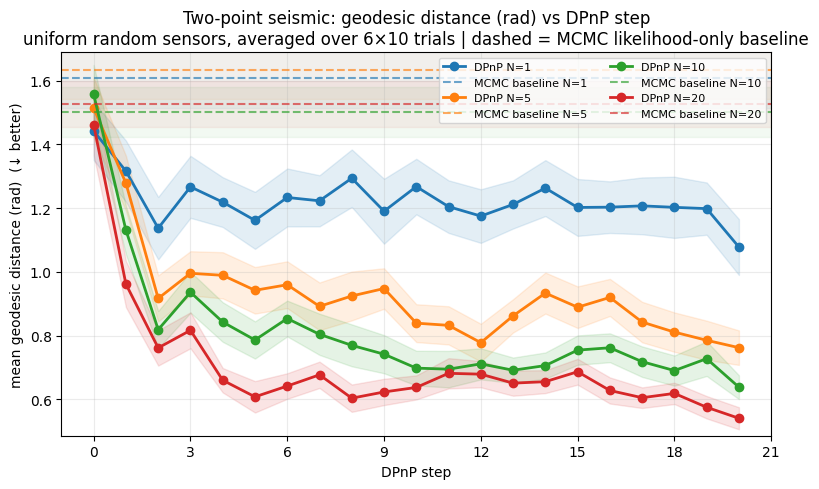

In [7]:
torch.manual_seed(0)
y1_fixed = normalize_torch(torch.randn(3, dtype=dtype, device=device))
y2_fixed = normalize_torch(torch.randn(3, dtype=dtype, device=device))

for yi, name in [(y1_fixed, "y1"), (y2_fixed, "y2")]:
    ll = extrinsic_to_latlon_deg_torch(yi[None]).squeeze()
    print(f"{name} (lat, lon) = ({ll[0].item():.2f}°, {ll[1].item():.2f}°)")

x_refl = _reflect_through_great_circle(x_true[None], y1_fixed[None], y2_fixed[None]).squeeze()
ll_r = extrinsic_to_latlon_deg_torch(x_refl[None]).squeeze()
print(f"x' reflection (lat, lon) = ({ll_r[0].item():.2f}°, {ll_r[1].item():.2f}°)")

demo_fixed = run_two_point_earthquake_demo(
    x_true=x_true,
    # y1=y1_fixed, y2=y2_fixed,
    beta=BETA, sigma2=SIGMA2,
    p_score=p_score, eta=eta,
    n_sensor_pairs=6,
    n_trials_per_sensor=10,
    metric="geodesic",
    n_bel_paths=5000, n_bel_steps=5,
    out_samples=32, grw_steps=5,
    particle_counts=[1, 5, 10, 20],
    plot_per_sensor=True,
    plot_global=True,
    plot_quality_vs_steps=True,
    include_baseline=True,   # geodesic random-walk Metropolis on S²
    mcmc_tau=1,
    mcmc_n_burnin=2000,
    mcmc_use_mala= True,
    show_kde= False,
    plot_3d= True,
    device=device, dtype=dtype, seed=0,
)

## 9. Geodesic distance vs steps – vMF sensors per x_true

DPnP:
  N =   1 | final step mean geodesic = 1.3220
  N =   5 | final step mean geodesic = 0.9537
  N =  10 | final step mean geodesic = 0.9001
  N =  20 | final step mean geodesic = 0.7852
MCMC baseline (likelihood-only):
  N =   1 | mean geodesic = 1.5733
  N =   5 | mean geodesic = 1.4337
  N =  10 | mean geodesic = 1.4023
  N =  20 | mean geodesic = 1.4366


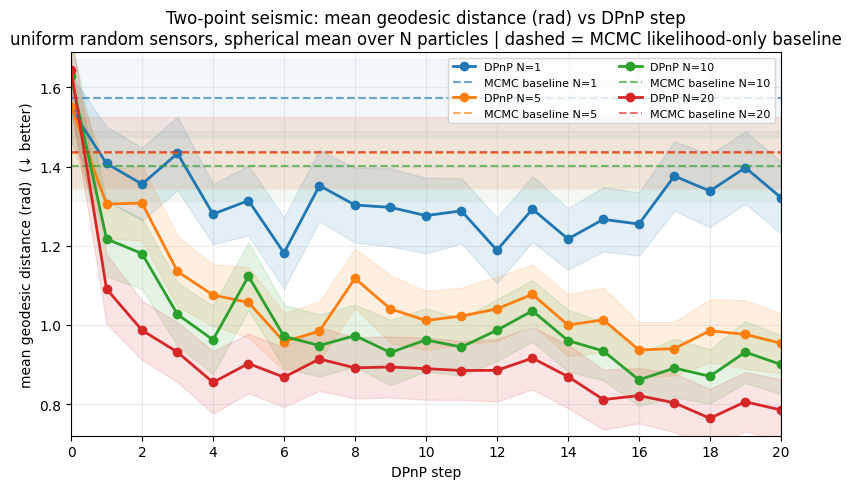

In [ ]:
summary_geo = cosine_similarity_vs_steps_two_point(
    dataloader=test_loader,
    p_score=p_score, eta=eta,
    # kappa_sensors=10.0,
    # kent_beta=3,
    beta=BETA, sigma2=SIGMA2,
    metric="geodesic",         # ← geodesic distance in degrees
    particle_counts=[1, 5, 10, 20],
    out_samples=20, grw_steps=5,
    num_pairs=64, batch_eval_size=8,
    n_bel_paths=5000, n_bel_steps=5,
    include_baseline=True,
    mcmc_n_burnin=2000,
    mcmc_use_mala=True,
    mcmc_tau=1,
    device=device, dtype=dtype, seed=0,
)


DPnP:
  N =  20 | final step mean geodesic = 0.8762
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.2648


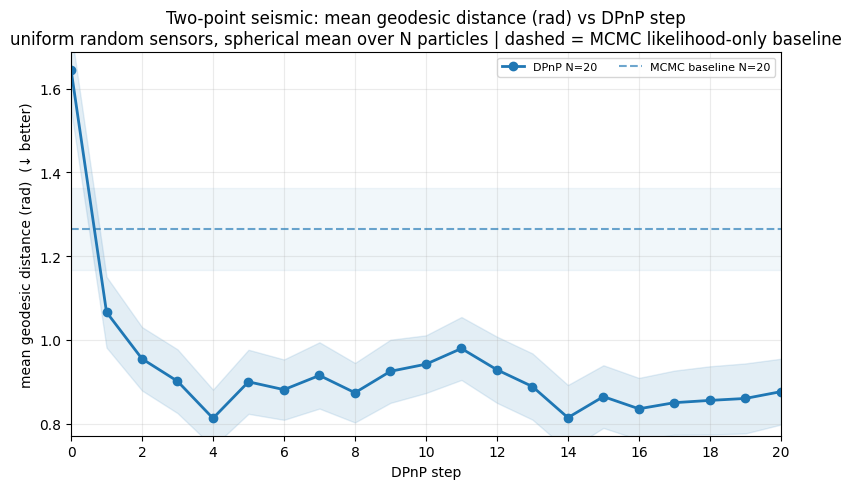

DPnP:
  N =  20 | final step mean geodesic = 0.8427
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.3283


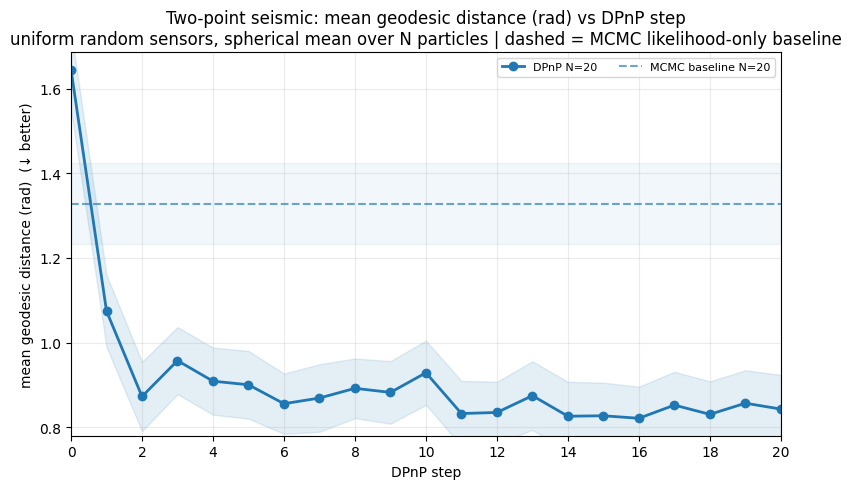

DPnP:
  N =  20 | final step mean geodesic = 0.8252
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.4173


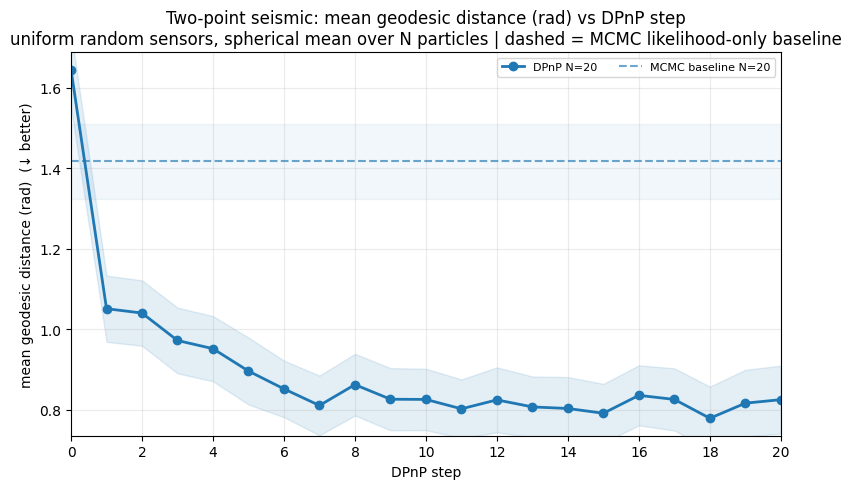

DPnP:
  N =  20 | final step mean geodesic = 0.7763
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.4366


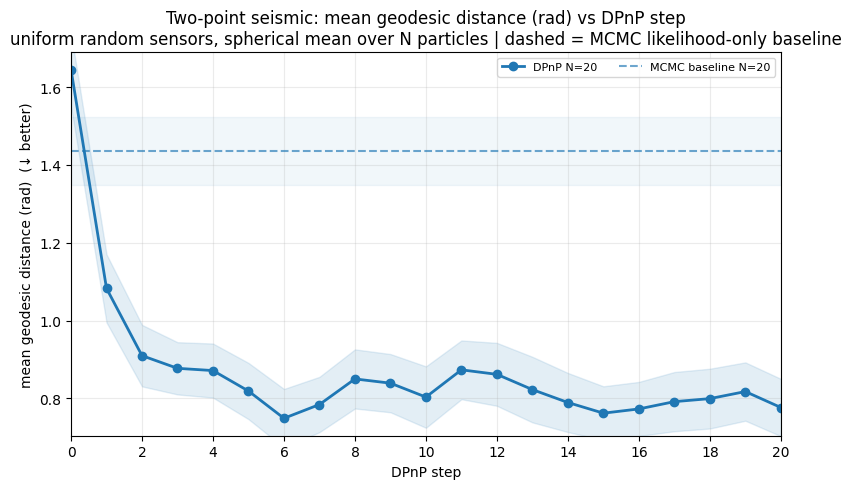

DPnP:
  N =  20 | final step mean geodesic = 0.8504
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.4484


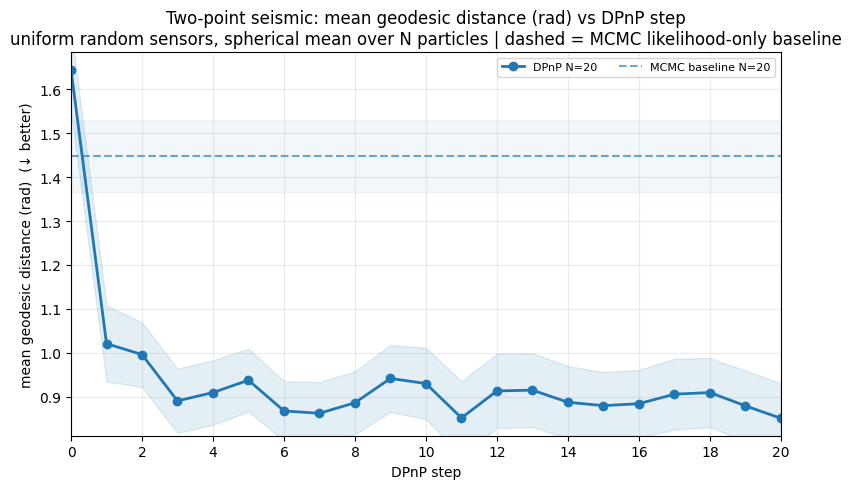

DPnP:
  N =  20 | final step mean geodesic = 0.8389
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.4319


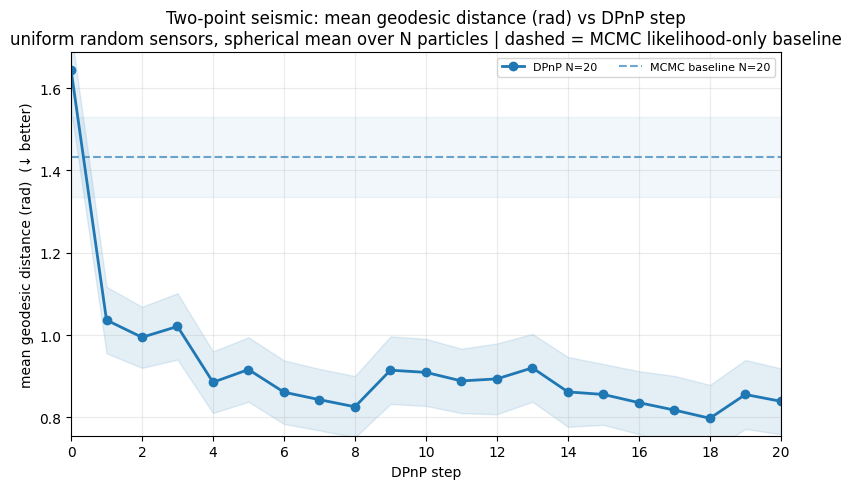

DPnP:
  N =  20 | final step mean geodesic = 0.8194
MCMC baseline (likelihood-only):
  N =  20 | mean geodesic = 1.4956


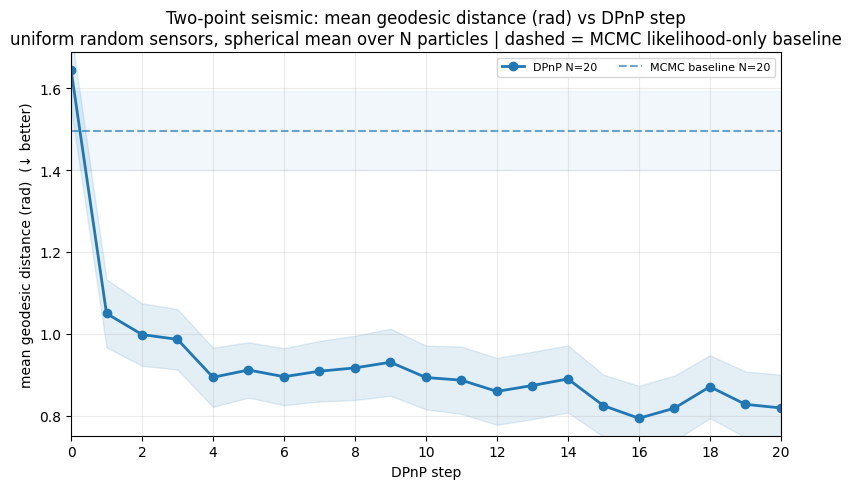

Text(0.5, 1.0, 'Geodesic distance vs tau in MALA')

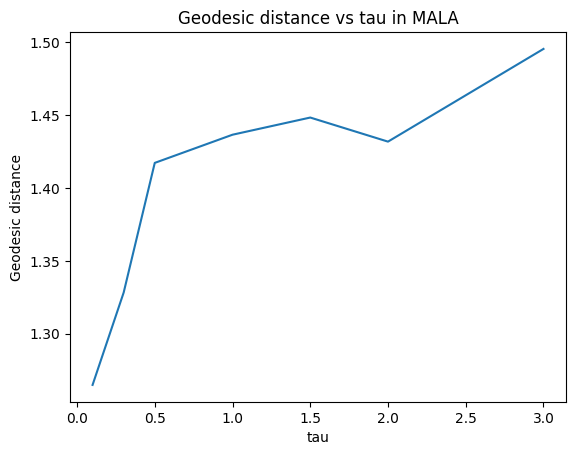

In [14]:
taus = [0.1, 0.3, 0.5, 1, 1.5,  2, 3]
res_baselines = {}
for tau in taus:
    res = cosine_similarity_vs_steps_two_point(
        dataloader=test_loader,
        p_score=p_score, eta=eta,
        # kappa_sensors=10.0,
        # kent_beta=3,
        beta=BETA, sigma2=SIGMA2,
        metric="geodesic",         # ← geodesic distance in degrees
        particle_counts=[20],
        out_samples=20, grw_steps=5,
        num_pairs=64, batch_eval_size=8,
        n_bel_paths=5000, n_bel_steps=5,
        include_baseline=True,
        mcmc_n_burnin=2000,
        mcmc_use_mala=True,
        mcmc_tau=tau,
        device=device, dtype=dtype, seed=0)
    res_baselines[tau] = res["baseline_by_particle_count"][20]["mean_score"] 
plt.plot(taus, [res_baselines[t] for t in taus])
plt.xlabel('tau')
plt.ylabel('Geodesic distance')
plt.title('Geodesic distance vs tau in MALA')

## 10. Effect of sensor concentration (kappa_sensors)

Compare reconstruction quality as sensors get closer to / farther from x_true.

In [6]:
kappas = [5.0, 15.0, 30.0, 50, 85, 100]
final_cos_by_kappa = {}
final_bl_by_kappa  = {}

for kappa_s in kappas:
    res = cosine_similarity_vs_steps_two_point(
        dataloader=test_loader,
        p_score=p_score, eta=eta,
        kappa_sensors=kappa_s,
        beta=BETA, sigma2=SIGMA2,
        metric="geodesic",
        particle_counts=[20],
        out_samples=32, grw_steps=5,
        num_pairs=40, batch_eval_size=40,
        n_bel_paths=5000, n_bel_steps=5,
        include_baseline=True,
        mcmc_n_burnin=2000,
        mcmc_use_mala=True,
        mcmc_tau=1,
        device=device, dtype=dtype, seed=0,
    )
    final_cos = res["by_particle_count"][20]["mean_score"][-1]
    final_bl  = res["baseline_by_particle_count"][20]["mean_score"]   # scalar
    final_cos_by_kappa[kappa_s] = final_cos
    final_bl_by_kappa[kappa_s]  = final_bl
    print(f"kappa_sensors={kappa_s:>5.1f}  |  DPnP={final_cos:.4f}  baseline={final_bl:.4f}")

kappa_vals = list(final_cos_by_kappa.keys())
plt.figure(figsize=(6, 4))
plt.plot(kappa_vals, [final_cos_by_kappa[k] for k in kappa_vals],
         marker="o", linewidth=2, label="DPnP (N=10)")
plt.plot(kappa_vals, [final_bl_by_kappa[k] for k in kappa_vals],
         marker="s", linewidth=2, linestyle="--", color="tab:pink",
         label="MCMC baseline (N=10)")
plt.xlabel(r"$\kappa_{\rm sensors}$ (sensor concentration)")
plt.ylabel("mean geodesic distance (rad)  (↓ better)")
plt.title("Reconstruction quality vs sensor concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 11. Tune MALA τ — uniform sensor setting

Sweep τ over a log-spaced grid with sensors drawn uniformly on S² and report three diagnostics:

| Diagnostic | What it measures | Target |
|---|---|---|
| **Acceptance rate** | Fraction of proposals accepted | ~0.574 (MALA optimal scaling) |
| **ESS** | Effective sample size via autocorrelation of ⟨x_t, x_true⟩ | maximise |
| **Geodesic distance** | Great-circle distance from chain mean to x_true | minimise |

The optimal τ is where ESS peaks — this typically coincides with acceptance rate near 0.57 for MALA.  
Set `use_mala=False` to run the same sweep for geodesic random walk (target acceptance ~0.234 in high dim, ~0.44 for 2-D).

In [ ]:
# ── MALA τ sweep ─────────────────────────────────────────────────────────────
tau_results_mala = tune_mala_tau(
    x_true=x_true,
    beta=BETA, sigma2=SIGMA2,
    n_chains=64,                        # parallel MCMC chains
    tau_values=np.logspace(-1.5, 1, 30),# τ from ~0.03 to 10
    n_samples=1000,
    n_burnin=500,
    use_mala=True,
    seed=0,
    device=device, dtype=dtype,
)
print(f"\nRecommended τ (MALA):  {tau_results_mala['best_tau_ess']:.4f}  (max ESS)")

# ── Geodesic random-walk τ sweep (for comparison) ────────────────────────────
tau_results_rw = tune_mala_tau(
    x_true=x_true,
    beta=BETA, sigma2=SIGMA2,
    n_chains=64,
    tau_values=np.logspace(-1.5, 1, 30),
    n_samples=1000,
    n_burnin=500,
    use_mala=False,
    seed=0,
    device=device, dtype=dtype,
)
print(f"\nRecommended τ (RW):    {tau_results_rw['best_tau_ess']:.4f}  (max ESS)")

## 11. Single-sensor vs two-sensor comparison

In [ ]:
from DPnP import dPnP_sampler_torch_batched
import math

sigma = math.sqrt(SIGMA2)
I1_true = seismic_signal(x_true, y1_fixed, BETA).item()
I2_true = seismic_signal(x_true, y2_fixed, BETA).item()

torch.manual_seed(0)
u1 = I1_true + sigma * torch.randn(1).item()
u2 = I2_true + sigma * torch.randn(1).item()

OUT_SAMPLES = 32

# ---- single sensor (y1 only) ----
q1 = get_bel(f_fn=get_seismic_f_fn(y1_fixed, u1, BETA, SIGMA2),
             n_paths=5000, n_steps=5, device=device, dtype=dtype)
X_1s = dPnP_sampler_torch_batched(
    q_score=q1, p_score=p_score, y=y1_fixed[None],
    out_samples=OUT_SAMPLES, eta=eta, grw_steps=5,
    seed=0, end_only=True, device=device, dtype=dtype,
)  # (1, P, 3)
cos_1s = (sphere_mean_torch(X_1s[0], dim=0) * x_true).sum().item()

# ---- two sensors ----
q2 = get_bel(f_fn=get_two_point_seismic_f_fn(y1_fixed, y2_fixed, u1, u2, BETA, SIGMA2),
             n_paths=5000, n_steps=5, device=device, dtype=dtype)
X_2s = dPnP_sampler_torch_batched(
    q_score=q2, p_score=p_score, y=y1_fixed[None],
    out_samples=OUT_SAMPLES, eta=eta, grw_steps=5,
    seed=0, end_only=True, device=device, dtype=dtype,
)  # (1, P, 3)
cos_2s = (sphere_mean_torch(X_2s[0], dim=0) * x_true).sum().item()

print(f"Single-sensor cosine = {cos_1s:.4f}")
print(f"Two-sensor   cosine = {cos_2s:.4f}")

for X_final, title_str in [
    (X_1s, f"Single sensor (y1) | cos={cos_1s:.4f}"),
    (X_2s, f"Two sensors (y1,y2) | cos={cos_2s:.4f}"),
]:
    plot_spherical_kde_mollweide(
        X_final=X_final,
        x_true=x_true,
        y_obs=torch.stack([y1_fixed, y2_fixed]),
        overlay_samples=True, overlay_y=True,
        title=title_str,
    )